<a href="https://colab.research.google.com/github/BillPapakyriakou/DataMining-Notebooks/blob/main/assignment_1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Πρώτη Σειρά Ασκήσεων – Μέρος B
---
### 5324 - Παπακυριακού Βασίλειος

### 5361 - Άννα Ταρασίδου



---
##**Βήμα 1 - Φόρτωση και καθαρισμός των δεδομένων**

In [2]:
import pandas as pd  # pandas
import numpy as np   # numpy
import ast           # ast : abstract syntax trees : χρήση συνάρτησης που μετατρέπει literal σε object, πχ list

# φορτώνει το αρχείο με τα metadata και αγνοεί τις κακές γραμμές
dataframe = pd.read_csv("sample_data/movies_metadata.csv", low_memory=False, on_bad_lines="skip")

columns_used = ["id", "title", "vote_count", "runtime", "vote_average",
    "revenue", "budget", "release_date", "genres"]    # λίστα με τα πεδία που θα χρησιμοποιήσουμε στο ερωτήματα 1-7

dataframe = dataframe[columns_used].copy()

numeric_columns = ["vote_count", "runtime", "vote_average", "revenue", "budget"]  # πεδία που πρέπει να είναι αριθμοί

for col in numeric_columns:   # για κάθε στήλη numeric
    dataframe[col] = pd.to_numeric(dataframe[col], errors="coerce")   # μετέτρεψε σε numeric (αν δεν είναι ήδη)
                                                                      # όπου δεν γίνεται - μετατροπή σε NaN

dataframe["release_date"] = pd.to_datetime(dataframe["release_date"], errors="coerce")  # μετατροπή σε data format (αν δεν είναι ήδη)
                                                                                        # όπου δεν γίνεται - μετατροπή σε NaN

# κάνει το πεδίο genres αντικείμενο python (λίστα από dictionaries αντί για string)
def fix_genres(val):
    if pd.isna(val):
        return np.nan
    try:
        # μετατροπή string τύπου [{"id":..., "name":...}] list από dictionaries
        return ast.literal_eval(val)
    except:
        return np.nan  # αν δεν γίνεται τότε NaN

dataframe["genres"] = dataframe["genres"].apply(fix_genres)

# αφαιρεί γραμμές με NaN (not a number) από τις columns που μας ενδιαφέρουν
dataframe.dropna(subset=["id", "title", "vote_count", "runtime", "vote_average",
    "revenue", "budget", "release_date", "genres"], inplace=True)

# αφαίρεση γραμμών με παράλογες τιμές

# runtime > 0 και < 300
dataframe = dataframe[(dataframe["runtime"] > 0) & (dataframe["runtime"] < 300)]

# vote_average μεταξύ 0 και 10
dataframe = dataframe[dataframe["vote_average"].between(0, 10)]

# budget και revenue μη αρνητικά
dataframe = dataframe[(dataframe["budget"] >= 0) & (dataframe["revenue"] >= 0)]

# τυπώνουμε συνολικό αριθμό rows και cols των δεδομένων
print("Τελικός αριθμός γραμμών:", dataframe.shape[0])
print("Τελικός αριθμός στηλών:", dataframe.shape[1])

# μερικά extra checks για το dataframe - TODO - περαιτέρω ανάλυση
#dataframe.info()
#dataframe.isna().sum()
#dataframe[numeric_columns].describe()
#dataframe["genres"].head(10)



Τελικός αριθμός γραμμών: 43476
Τελικός αριθμός στηλών: 9


---
##**Βήμα 2 - Ανάλυση κατανομής του πεδίου vote_counts**

### 2.1 Ιστόγραμμα του vote_count (100 bins)

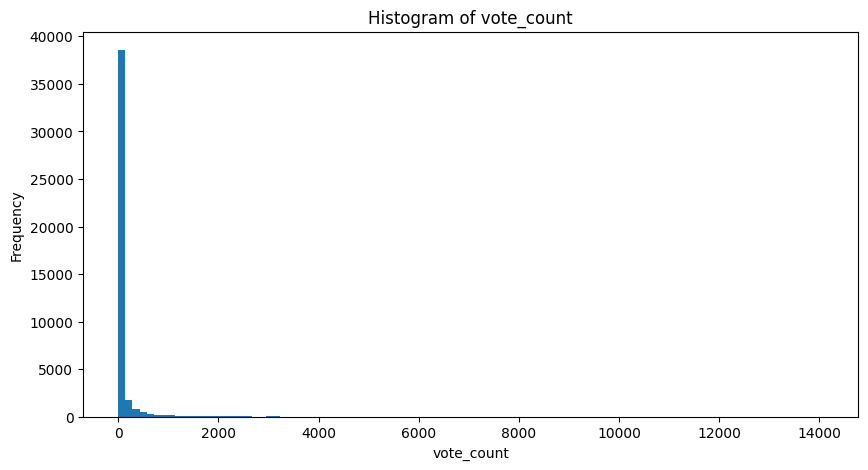

In [3]:
import matplotlib.pyplot as plt

vote_counts = dataframe['vote_count'].values

plt.figure(figsize=(10,5))
plt.hist(vote_counts, bins=100)
plt.title("Histogram of vote_count")
plt.xlabel("vote_count")
plt.ylabel("Frequency")
plt.show()

Από το ιστόγραμμα παρατηρούμε αρχικά ότι η κατανομή είναι πολύ right skewed. Η συντιπτική πλειοψηφία των ταινιών έχει πολύ λίγα votes, ενώ οι ταινίες που έχουν πολλά votes (>1000) είναι λίγες. Το συμπέρασμα είναι ότι οι περισσότερες ταινίες παίρνουν λίγη προσοχή ενώ λίγες είναι αυτές που συγκεντρώνουν μεγάλο ενδιαφέρον.

### 2.2 Ιστόγραμμα με εκθετικά bins (log-log plot)

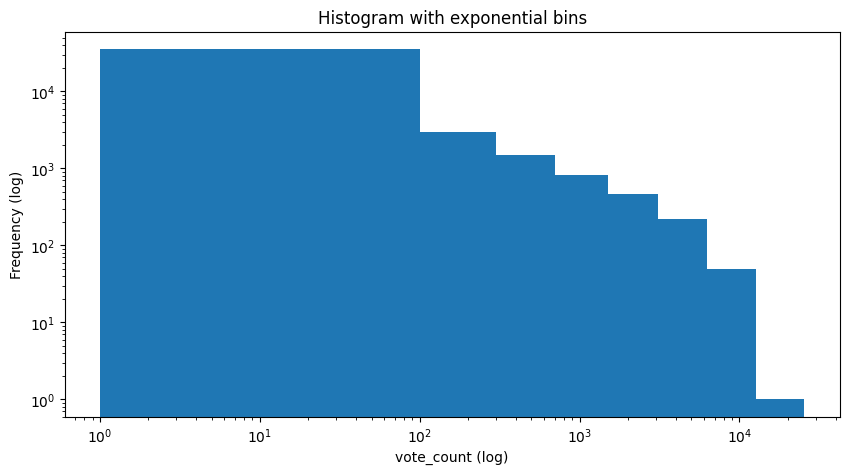

In [16]:
bins = [1]      # ξεκινάμε από 1
current = 100   # μέγεθος πρώτου κάδου

# βρίσκει το μέγιστο vote_count
max_votes = vote_counts.max()

while bins[-1] < max_votes:
    bins.append(bins[-1] + current)
    current *= 2                     # διπλασιασμός μεγέθους κάδου
bins = np.array(bins)


plt.figure(figsize=(10,5))
plt.hist(dataframe["vote_count"], bins=bins)
plt.xscale("log")
plt.yscale("log")
plt.title("Histogram with exponential bins")
plt.xlabel("vote_count (log)")
plt.ylabel("Frequency (log)")
plt.show()

Από το καινούριο ιστόγραμμα βλέπουμε καλύτερα τις διαφορές. Το πρώτο bin είναι το μεγαλύτερο σε μέγεθος, μας δείχνει δηλαδή ότι οι περισσότερες ταινίες στα δεδομένα μας έχουν λίγα votes (<=100). Μετά στα επόμενα 5 bins παρατηρούμε μια σχεδόν γραμμική μέιωση υποδηλώνοντας ότι το πλήθος των ταινιών πέφτει πολύ γρήγορα καθώς αυξάνεται το vote count. Το τελευταίο bin είναι το μικρότερο κατά πολύ συγκριτικά με τα προηγούμενα. Αυτό μας επιβεβαιώνει πως οι ταινίες με πολύ μεγάλο αριθμό ψήφων είναι πάρα πολύ λίγες.  

### 2.3 Cumulative frequency plot (log-log)

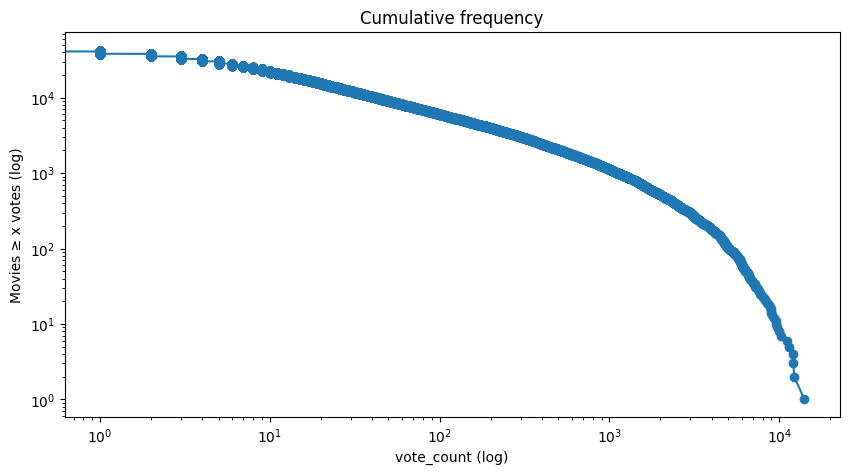

In [18]:
# κάνει ταξινόμηση από τον μικρότερο προς τον μεγαλύτερο αριμθό ψήφων
votes_sorted = np.sort(vote_counts)

# κρατάει αριθμό εγγραφών με τουλάχιστον x ψήφους
cumulative_freq = np.arange(len(votes_sorted), 0, -1)

plt.figure(figsize=(10,5))
plt.plot(votes_sorted, cumulative_freq, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.title("Cumulative frequency")
plt.xlabel("vote_count (log)")
plt.ylabel("Movies ≥ x votes (log)")
plt.show()

Το culuvative frequency διάνυσμα μειώνεται αργά για μικρό αριθμό vote counts και πιό γρήγορα όταν έχουμε μεγάλο αριθμό vote counts. Η εικόνα συνολικά δείχνει ότι:

- έχουμε πολλές ταινίες με λίγα votes
- λίγες ταινίες με πάρα πολλά votes

### 2.4 Zipf plot (log-log)

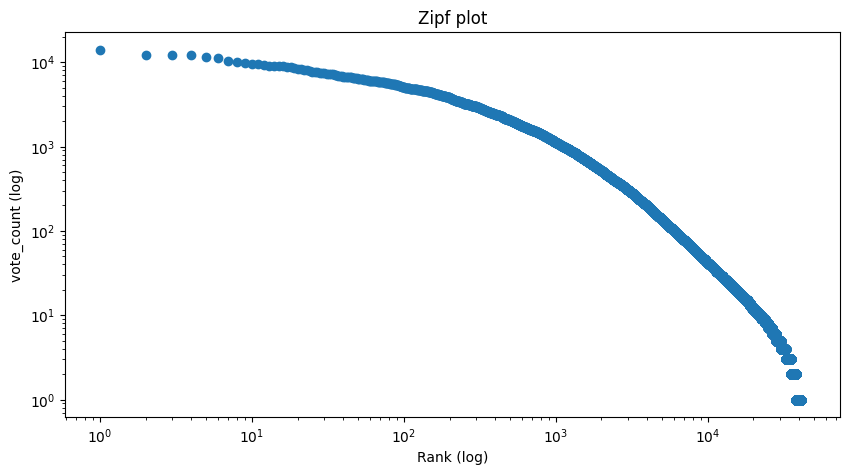

In [17]:
# κάνει ταξινόμηση από τον μεγαλύτερο προς τον μικρότερο αριμθό ψήφων
votes_desc = np.sort(vote_counts)[::-1]

# δημιουργεί τα rank
rank = np.arange(1, len(votes_desc)+1)

plt.figure(figsize=(10,5))
plt.scatter(rank, votes_desc)
plt.xscale('log')
plt.yscale('log')
plt.title("Zipf plot")
plt.xlabel("Rank (log)")
plt.ylabel("vote_count (log)")
plt.show()

Με το Ζipf-plot ταξινομούμε τις ταινίες από δημοφιλή σε λιγότερο δημοφιλή και συγκρίνουμε το rank. Βλέπουμε πιο ξεκάθαρα ότι η πιο δημοφιλής ταινία ξεχωρίζει έντονα, έχοντας αρκετά περισσότερα votes από τις επόμενες. Η διαφορά αυτή συνεχίζει και στις υπόλοιπες δείχνοντας ότι το popularity μειώνεται γρήγορα από την κορυφή πρός τις μικρότερες θέσεις.

### 2.5 Ιστόγραμμα της λογαριθμικής μεταβλητής log_votes (100 bins)

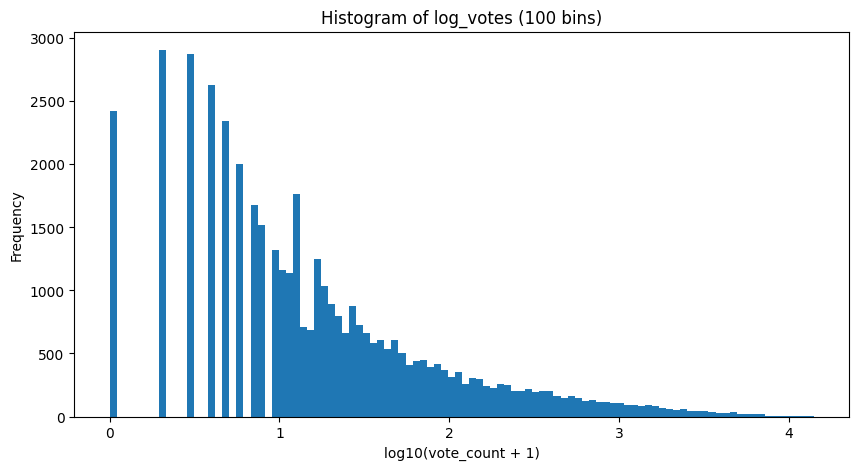

In [7]:
dataframe['log_votes'] = np.log10(dataframe['vote_count'] + 1)  # +1 για να μην έχουμε log(0)

# Ιστόγραμμα με 100 bins
ax = dataframe['log_votes'].plot(kind='hist', bins=100, figsize=(10,5))

ax.set_xlabel("log10(vote_count + 1)")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of log_votes (100 bins)")
plt.show()

Παρατηρούμε ότι μετά τη λογαριθμική μετατροπή, η κατανομή μας αρxίζει να ακολουθεί περίπου την κατανομή log-normal. Πλέον τα δεδομένα είναι πιό ισορροπημένα και η ανάλυση γίνεται πιό εύκολη καθώς η αρχική κατανομή από το 2.1 ήταν κυριαρχημένη από τα πολύ μικρά ή τα πολύ μεγάλα values. Πλέον μπορούμε να εξάγουμε τη χρήσιμη πληροφορία από την πλειονότητα των τιμών, ενώ ταυτόχρονα να βλέπουμε και την επίδραση των ακραίων τιμών.


---
##**Βήμα 3 - Ανάλυση συσχέτισης runtime με vote_average, budget, και revenue**

Number of movies after filtering: 4994


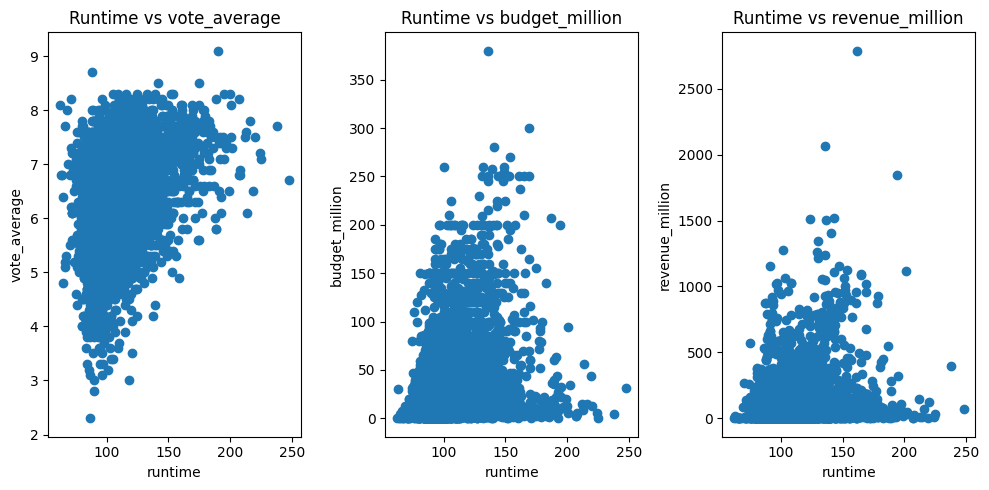


Correlation runtime vs vote_average: 0.363, p-value: 2.488e-155
Correlation runtime vs budget_million: 0.200, p-value: 4.476e-46
Correlation runtime vs revenue_million: 0.199, p-value: 5.821e-46


In [25]:
# import για το Pearson Correlation Coefficient
from scipy.stats import pearsonr

# νέο dataframe για το βήμα 3
dataframe3 = dataframe.copy()

# κρατάει τις ταινίες που θέλουμε για να βρούμε τη συσχέτιση
dataframe3 = dataframe3[(dataframe3["runtime"] > 30 ) & (dataframe3["vote_count"] > 10 ) & (dataframe3["budget"] > 20000) & (dataframe3["revenue"]  > 20000)]

# νέα columns με το budget και το revenue σε millions
dataframe3['budget_million'] = dataframe3['budget'] / 1e6
dataframe3['revenue_million'] = dataframe3['revenue'] / 1e6

print("Number of movies after filtering:", len(dataframe3))

# πεδία που χρειάζονται για την συσχέτιση
fields = ['vote_average', 'budget_million', 'revenue_million']

plt.figure(figsize=(10,5))

# scatter plot για κάθε πεδίο
for i, field in enumerate(fields):
    plt.subplot(1, 3, i+1)
    plt.scatter(dataframe3['runtime'], dataframe3[field])
    plt.xlabel("runtime")
    plt.ylabel(field)
    plt.title(f"Runtime vs {field}")

plt.tight_layout()
plt.show()

print("")
for field in fields:
    corr, p_value = pearsonr(dataframe3['runtime'], dataframe3[field])
    print(f"Correlation runtime vs {field}: {corr:.3f}, p-value: {p_value:.3e}")

---
### Συμπεράσματα:
---
### Runtime vs vote_average
- Παρατηρούμε ότι η συσχέτιση είναι περίπου 0.36, θετική όμως όχι πολύ μεγάλη. Το p-value βγάινει πολύ κοντά στο 0, πράγμα που δείχνει πως η συσχέτιση είναι στατιστικά σημαντική. Κοιτώντας το scatter plot μπορούμε να παρατηρήσουμε μια μικρή άνοδο των σημείων, όμως η κατανομή μας είναι αρκετά απλωμένη. Συνεπώς μπορούμε να πούμε ότι όσο το runtime μεγαλώνει παρατηρείτε μια τάση για υψηλότερο vote_average, όμως δεν είναι αρκετά ξεκάθαρο για να πούμε ότι η διάρκεια εξηγεί τις αξιολογήσεις.

### Runtime vs budget
- Εδώ βλέπουμε ακόμα πιο μικρή συσχέτιση (περίπου 0.2) και πολύ μικρό p-value, επομένως υπάρχει μια πραγματική σχέση που είναι όμως ασθενής. Με βάση το scatter plot βλέπουμε στην αρχή μια ανοδική πορεία όμως για μεγάλα runtimes (>150) το budget αρχίζει και μειώνεται αρκετά απότομα. Ταινίες μεγάλης διάρκειας τείνουν να έχουν λίγο μεγαλύτερο budget άλλα η σχέση παραμένει αδύναμη. Η διάρκεια δεν είναι καθοριστικός παράγοντας για το budget.

### Runtime vs revenue
- Ομοίως έχουμε μικρή συσχέτιση (περίπου 0.2) και p-value κοντά στο 0. Το scatter plot μοιάζει αρκετά αυτό του runtime vs budget, παρατηρούμε δηλαδή μια αύξηση στο revenue μέχρι ένα σημείο (περίπου 140 runtime) και μετά πέφτει. Υπάρχει μια τάση οι μεγαλύτερες ταινίες να έχουν μεγαλύτερο revenue άλλα η σχέση παραμένει ασθενής, δεν μπορούμε να πούμε ότι η διάρκεια προβλέπει καθοριστικά τα έσοδα μιας ταινίας.


---
##**Βήμα 4 - Ελέγχοντας την υπόθεση ότι οι παλιές ταινίες Είναι καλύτερες**

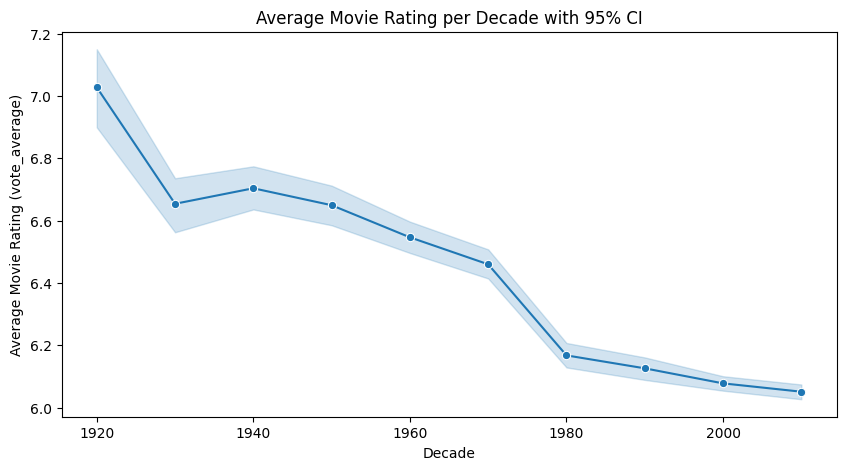

In [9]:
import seaborn as sb

# νέο dataframe για το βήμα 4
dataframe4 = dataframe.copy()

# αφήνουμε μόνο ταινίες με vote_count >= 10
dataframe4 = dataframe4[pd.to_numeric(dataframe4['vote_count'], errors='coerce') >= 10]

# από το release date κρατάμε τουε 4 πρώτους χαρακτήρες (το έτος)
dataframe4['year'] = pd.to_numeric(dataframe4['release_date'].astype(str).str[:4], errors='coerce')

# αφαιρούμε γραμμές χωρίς έτος
dataframe4 = dataframe4.dropna(subset=['year'])

# δημιουργία decade από έτος
# πχ: 1997 // 10 = 199 * 10 = 1990 (δεκαετία)
dataframe4['decade'] = (dataframe4['year'] // 10) * 10

# κρατάμε μόνο δεκαετίες με τουλάχιστον 50 ταινίες
decade_counts = dataframe4['decade'].value_counts()
valid_decades = decade_counts[decade_counts >= 50].index
dataframe4 = dataframe4[dataframe4['decade'].isin(valid_decades)]

# μετατρέπουμε vote_average σε numeric
dataframe4['vote_average'] = pd.to_numeric(dataframe4['vote_average'], errors='coerce')

# αφαιρούμε γραμμές χωρίς vote_average
dataframe4 = dataframe4.dropna(subset=['vote_average'])

# lineplot με μέση ποιότητα και 95% confidence interval (CI)
plt.figure(figsize=(10,5))
sb.lineplot(data=dataframe4, x='decade', y='vote_average', errorbar=('ci', 95), marker='o')
plt.xlabel("Decade")
plt.ylabel("Average Movie Rating (vote_average)")
plt.title("Average Movie Rating per Decade with 95% CI")
plt.show()

Η γραφική δείχνει ότι το μέσο rating των ταινιών μειώνεται με μια μικρή εξαίρεση το 1930-1940 που υπάρχει αύξηση. Άυτό σημαίνει ότι οι παλιότερες ταινίες πράγματι έχουν υψηλότερες βαθμολογίες από τις πιό καινούριες. Η μπλέ περιοχή γύρω από τη γραμμή (confidence interval 95%) φαίνεται να στενεύει καθώς προχωράμε στις επόμενες δεκαετίες, υποδηλώνοντας ότι οι μέσες τιμές είναι πιό αξιόπιστες όταν υπάρχουν περισσότερες ταινίες με αρκετά votes.

### **BONUS - Πιό ρεαλιστική μέση ποιότητα ταινιών χρησιμοποιώντας σταθμισμένο μέσου όρο**


Η μέση βαθμολογία μπορεί να βγάζει καλύτερες τις παλιότερες ταινίες διότι στο dataset υπάρχουν λίγες ταινίες και κατά πάσα ποθανότητα οι πιό γνωστές από τις παλιές δεκαετίες. Για να το αντιμετωπίσουμε αυτό θα πάρουμε τον σταθμισμένο μέσο όρο, όπου κάθε ταινία θα γυγίζεται με το vote_count. Με αυτόν τον τρόπο, οι ταινίες με περισσότερους ψήφους θα έχουν μεγαλύτερη επιρροή στη μέση τιμή και αυτές με λίγες ψήφους δεν θα την επηρεάζουν τόσο πολύ.  

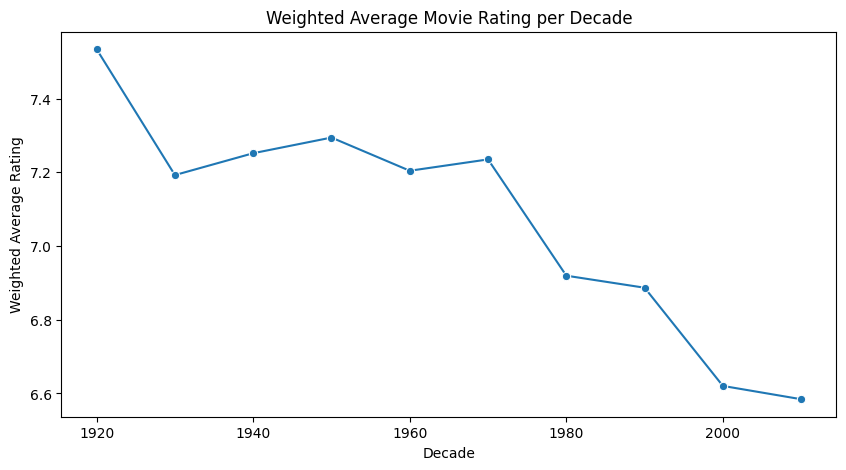

In [10]:
# φτιάχνουμε νέα στήλη weighted_score = vote_average * vote_count
dataframe4['weighted_score'] = dataframe4['vote_average'] * dataframe4['vote_count']

# group ανά δεκαετία και υπολογίζουμε άθροισμα των weighted_score και συνολικό πλήθος των vote_count (για κάθε decade)
weighted_sum = dataframe4.groupby('decade')['weighted_score'].sum()
total_votes = dataframe4.groupby('decade')['vote_count'].sum()

# σταθμισμένος μέσος όρος
weighted_avg = (weighted_sum / total_votes).reset_index(name='weighted_vote_average')

# lineplot
plt.figure(figsize=(10,5))
sb.lineplot(data=weighted_avg, x='decade', y='weighted_vote_average', marker='o')
plt.xlabel("Decade")
plt.ylabel("Weighted Average Rating")
plt.title("Weighted Average Movie Rating per Decade")
plt.show()

Η καινούρια γραφική συνεχίζει να μας δείγχνει μια μείωση στα ratings των ταινιών με το πέρασμα των δεκαετίων, αν και υπάρχουν δύο ανοδικά σημεία (1930-1950, 1960-1970). Παρόλο που χρησιμοποιοήσαμε σταθμισμένη προσέγγιση, εξακολουθούμε να παρατηρούμε αυτό που βλέπαμε στο ερώτημα 4. Αυτό μπορεί να οφείλεται στο γεγονός ότι με την πάροδο του χρόνου κυκλοφορούν περισσότερες νέες ταινίες, πολλές από τις οποίες ενδέχεται να μην έχουν υψηλή ποιότητα, καθώς επίσης και στο ότι συνήθως καταγράφονται κυρίως οι πιο δημοφιλείς παλιές ταινίες, ενώ για τις σύγχρονες υπάρχουν περισσότερες εγγραφές ανεξαρτήτως δημοφιλίας.

---
σχολιο: οι γραφικες στο 2 βγαινουν διαφορετικες πλεον και ο σχολιασμος τους θελει διορθωση!!! η κατανομη ειναι log-normal στο 2.5
---

---
##**Βήμα 5 - Ανάλυση συσχέτισης μεταξύ φύλου σκηνοθέτη και genre ταινιών**

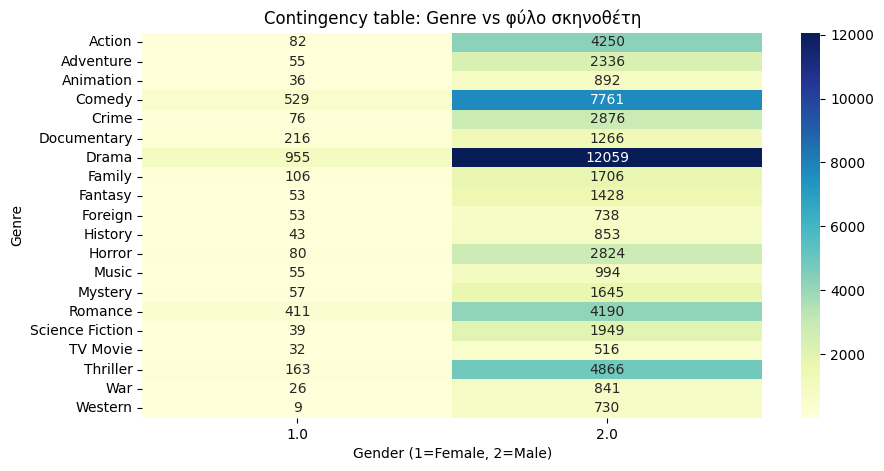


Chi2: 873.3669672305259
p-value: 5.297781649229894e-173
-------------------------------
gender                1.0       2.0
genre                              
Action           0.355661  1.036220
Adventure        0.432210  1.031917
Animation        0.728897  1.015240
Comedy           1.198982  0.988815
Crime            0.483736  1.029021
Documentary      2.738527  0.902271
Drama            1.378809  0.978706
Family           1.099155  0.994426
Fantasy          0.672407  1.018415
Foreign          1.258957  0.985443
History          0.901720  1.005525
Horror           0.517613  1.027117
Music            0.985142  1.000835
Mystery          0.629255  1.020841
Romance          1.678422  0.961864
Science Fiction  0.368604  1.035493
TV Movie         1.097188  0.994537
Thriller         0.609000  1.021979
War              0.563463  1.024539
Western          0.228828  1.043350


In [11]:
import json
import seaborn as sb
from scipy.stats import chi2_contingency

# παίρνουμε τα genres από το dataframe των ταινιών
#movies = pd.read_csv("sample_data/movies_metadata.csv", low_memory=False, on_bad_lines="skip")
movies = dataframe.copy()

# μετατρέπει το πεδίο genres σε λίστα από dictionaries
def parse_genres(x):
    # αν η τιμή είναι λίστα, την κρατάμε
    if isinstance(x, list):
        return x
    if pd.isnull(x):  # αν η τιμή είναι NaN τότε return άδεια λίστα
        return []
    try:
        return json.loads(x.replace("'", "\""))  # αντικατάσταση μονών εισαγωγικών σε διπλά
    except:
        return []

# εφαρμόζει το parsing στη στήλη genres
movies['genres'] = movies['genres'].apply(parse_genres)

# μετατρέπουμε κάθε στοιχείο της λίστας genres σε ξεχωριστή γραμμή του πίνακα
# ώστε να έχουμε ένα dataframe με κάθε γραμμή να περιέχει τον συνδιασμό id και genre
movies_genres = movies[['id','genres']].explode('genres')

# παίρνει μόνο το όνομα του genre (αν υπάρχει)
movies_genres['genre'] = movies_genres['genres'].apply(
    lambda g: g['name'] if isinstance(g, dict) and 'name' in g else None
)
movies_genres = movies_genres.dropna(subset=['genre'])  # αφαίρεση κενών

# δεν κρατάμε genres με λιγότερες από 100 ταινίες
genre_counts = movies_genres['genre'].value_counts()
valid_genres = genre_counts[genre_counts > 100].index
movies_genres = movies_genres[movies_genres['genre'].isin(valid_genres)]


# παίρνουμε το dataframe με τα credits των ταινιών
credits = pd.read_csv("sample_data/credits.csv")

# επιστρέφει το φύλο και το όνομα του σκηνοθέτη ( None, None αν δεν υπάρχει)
def get_director_gender(crew_list):
    # αν είναι string το input
    if isinstance(crew_list, str):
        try:
            crew_list = eval(crew_list) # μετατροπή σε python list (από string)
        except:
            return None, None  # αν δεν γίνεται - return (None, None)
    # αν είναι λίστα (ή έχει πλέον γίνει λίστα)
    if isinstance(crew_list, list):
        # ψάχνει για directors και παίρνει το όνομα και το gender τους
        for member in crew_list:
            if member.get('job') == 'Director':
                return member.get('gender'), member.get('name')
    return None, None

# δημιουργία 2 cols - gender και director
credits[['gender', 'director']] = credits['crew'].apply(lambda x: pd.Series(get_director_gender(x)))
credits = credits.dropna(subset=['gender'])
credits = credits[credits['gender'].isin([1,2])]  # για να κρατάει μόνο τα γνωστά genders

# μετατροπή των δύο id σε string για να ταιριάξουν στο καινούριο dataframe
movies_genres['id'] = movies_genres['id'].astype(str)
credits['id'] = credits['id'].astype(str)

# inner join των δύο dataset στο πεδίο id
dataframe5 = pd.merge(movies_genres, credits[['id','gender']], on='id', how='inner')

# δημιουργία contingency table
contingency = pd.crosstab(dataframe5['genre'], dataframe5['gender'])

# δημιουργία και plot του heatmap
plt.figure(figsize=(10,5))
sb.heatmap(contingency, annot=True, fmt="d", cmap="YlGnBu")  # εμφανίζει τις τιμές στο heatmap
plt.xlabel("Gender (1=Female, 2=Male)")
plt.ylabel("Genre")
plt.title("Contingency table: Genre vs φύλο σκηνοθέτη")
plt.show()

# chi2-test και αποτελέσματα
# εξετάζει τη συσχέτιση μεταξύ του φύλου του σκηνοθέτη και του είδος της ταινίας που σκηνοθετούν
chi2, p, dof, expected = chi2_contingency(contingency)
print("")
print("Chi2:", chi2)
print("p-value:", p)  # αν το p-value είναι πολύ μικρό (πχ < 0.05) υπάρχει σημαντική συσχέτιση
print("-------------------------------")

# υπολογισμός lift και αποτελέσματα
# δείχνει σε ποιο βαθμό εμφανίζονται τα ζευγάρια είδος - φύλλο σκηνοθέτη
lift = contingency / expected
print(lift)



### Ανάλυση αποτελεσμάτων

Το chi squared test μας δίνει η τιμή για το p-value να είναι πάρα πολύ κοντά στο μηδέν. Αυτό σημαίνει ότι η συσχέτιση μεταξύ φύλου σκηνοθέτη και είδους ταινίας είναι στατιστικά σημαντική.

Οι τιμές από το lift μας δείχνουν ότι οι γυναίκες directors είναι πιό πιθανό να σκηνοθετήσουν ταινίες με είδος Documentary (2.738), Romance (1.678) και Foreign (1.258) και λιγότερο πιθανό να σκηνοθετήσουν Science Fiction (0.368), Action (0.355) και Western (0.228).     

Αντίστοιχα οι άντρες είναι πίο πιθανό να σκηνοθετήσουν Western (1.043), Action (1.036) και Science Fiction (1.035) και λιγότερο πιθανό Documentary (0.902), Romance (0.961) και Drama (0.978).

Το συμπέρασμα είναι πως σαφώς υπάρχει προτίμηση φύλου για συγκεκριμένα είδη, ειδικά στις γυναίκες που σημειώνονται και μεγαλύτερες διαφορές στα lift.

---
##**Βήμα 6 - Σύγκριση Μέσων Τιμών για Action και Drama: Revenue, Budget και Vote Average**

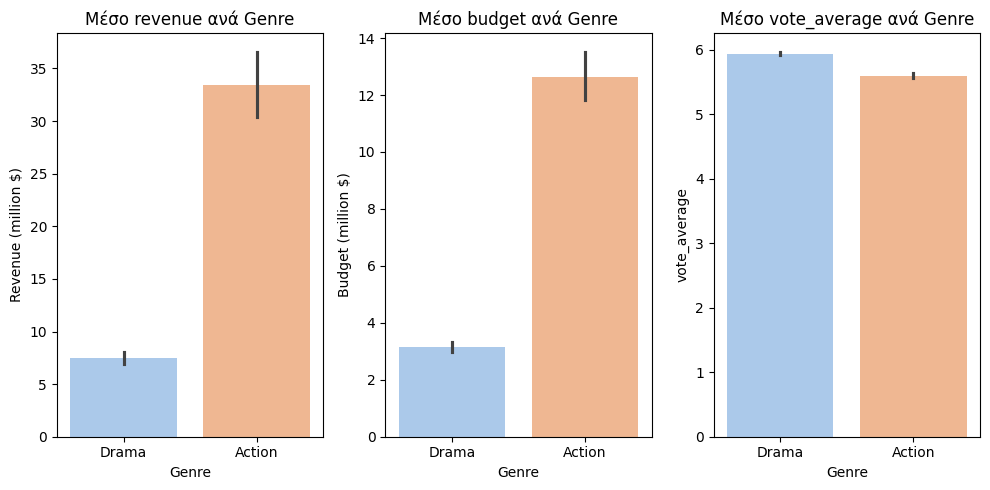


revenue - t-statistic: 15.296, p-value: 7.263e-52
budget - t-statistic: 20.977, p-value: 1.912e-94
vote_average - t-statistic: -14.832, p-value: 2.737e-49


In [12]:
from scipy.stats import ttest_ind

# κρατάμε μόνο τα genres Action και Drama στο dataframe
dataframe6 = movies[movies['genres'].apply(lambda x: any(d['name'] in ['Action','Drama'] for d in x))].copy()

# φτιάχνουμε στήλη genre που θα περιέχει μόνο το κύριο genre (μερικές ταινίες έχουν πολλά)
# κρατάμε μόνο αν είναι action ή drama
def get_primary_genre(genres_list):
    for g in genres_list:
        if g['name'] in ['Action','Drama']:
            return g['name']
    return None

dataframe6['primary_genre'] = dataframe6['genres'].apply(get_primary_genre)  # εφαρμογή φίλτρου - συνάρτησης

# μετατροπή στήλων από string σε αριθμούς και αφαίρεση NaN γραμμών
dataframe6['revenue'] = pd.to_numeric(dataframe6['revenue'], errors='coerce')
dataframe6['budget'] = pd.to_numeric(dataframe6['budget'], errors='coerce')
dataframe6['vote_average'] = pd.to_numeric(dataframe6['vote_average'], errors='coerce')


# φτιάχνουμε νέα στήλη για το budget σε millions (μετατροπή για τις γραφικές)
dataframe6['budget_million'] = dataframe6['budget'] / 1e6

# φτιάχνουμε νέα στήλη για το revenue σε millions (μετατροπή για τις γραφικές)
dataframe6['revenue_million'] = dataframe6['revenue'] / 1e6


fig, axes = plt.subplots(1, 3, figsize=(10,5))
attributes = ['revenue', 'budget', 'vote_average']  # πεδία που συγκρίνονται

for i, attr in enumerate(attributes):
    if attr == 'budget':
      plot_attr = 'budget_million'
    elif attr == 'revenue':
      plot_attr = 'revenue_million'
    else:
      plot_attr = attr
    # barplot με 95% διάστημα εμπιστοσύνης στο errorbar
    sb.barplot(
        data=dataframe6,
        x='primary_genre',
        y=plot_attr,
        hue='primary_genre',
        errorbar=('ci', 95),
        ax=axes[i],
        palette='pastel',
        legend=False
    )

    axes[i].set_title(f'Μέσο {attr} ανά Genre')
    if attr == 'budget':
        axes[i].set_ylabel('Budget (million $)')
    elif attr == 'revenue':
        axes[i].set_ylabel('Revenue (million $)')
    else:
        axes[i].set_ylabel(attr)
    axes[i].set_xlabel('Genre')

# για να μην μπαίνουν το ένα γράφημα πάνω στο άλλο
plt.tight_layout()
plt.show()

# κάνουμε τα t-test
print("")
# για κάθε attribute κάνουμε t-test μεταξύ Drama και Action genres
for attr in attributes:
    # παίρνουμε τις τιμές αφαιρόντας NaN τιμές
    action_vals = dataframe6[dataframe6['primary_genre']=='Action'][attr].dropna()
    drama_vals = dataframe6[dataframe6['primary_genre']=='Drama'][attr].dropna()

    t_stat, p_val = ttest_ind(action_vals, drama_vals, equal_var=False)  # t-test εδώ
    # το t-statistic το επιστρέφει η ttest_ind() και δηλώνει κατά πόσο
    # μικρότερη ή μεγαλύτερη είναι η μέση τιμή του ενός genre σε σχέση με το άλλο
    # πχ : t-stat = 10 - μέση τιμή action > μέση τιμή drama
    #      t-stat = -10 - μέση τιμή action < μέση τιμή drama
    print(f"{attr} - t-statistic: {t_stat:.3f}, p-value: {p_val:.3e}")

### Ανάλυση αποτελεσμάτων

Από τις γραφικές παραστάσεις παρατηρούμε ξεκάθαρα ότι οι ταινίες action έχουν πολύ μεγαλύτερο μέσο revenue και μέσο budget σε σχέση με τις ταινίες drama. Παρόλα αυτά στο γράφημα με τις βαθμολογίες βλέπουμε ότι οι drama είναι rated πιο ψηλά από τις action κατά μέσο όρο.

Αξίζει να πούμε επιπλέον ότι τα 95% confidence intervals μεταξύ των δύο genres δεν επικαλύπτονται. Προτού συμβουλευτούμε το t-test χρησιμοπιούμε αυτό ως επιπλέον ένδειξη ότι οι διαφορές στις μέσες τιμές είναι πραγματικές και δεν οφείλονται σε φαινόμενα όπως ακραίες τιμές.

Για να καταλάβουμε αν αυτές οι διαφορές είναι στατιστικά σημαντικές θα πρέπει να συμβουλευτούμε το t-test.

Πράγματι τα p-values σε κάθε σύγκριση βγαίνουν να είναι πολύ κοντά στο 0, πράγμα που κάνει τις διαφορές στατιστικά σημαντικές.

---
##**Βήμα 7 - Ανάλυση υπόθεσης - Έχουν οι γυναίκες σκηνοθέτες μικρότερο budget από τους άντρες σκηνοθέτες;**

T-test for budget difference by director gender
t-statistic: -6.941673117774318
p-value: 5.1028041411894864e-12



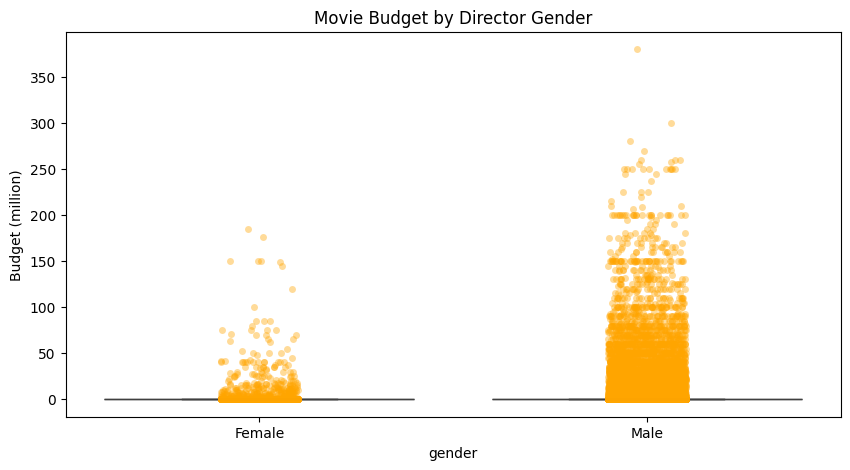

In [26]:
# παίρνουμε τις ταινίες
movies = dataframe.copy()
movies['id'] = movies['id'].astype(str)  # κάνουμε το id string για το merge

# κρατάμε το id και το budget από τις ταινίες
movies_budget = movies[['id', 'budget']].copy()

# μετατροπή budget σε αριθμό
movies_budget['budget'] = pd.to_numeric(movies_budget['budget'], errors='coerce')

# παίρνουμε τα credits
credits = pd.read_csv("sample_data/credits.csv")
credits['id'] = credits['id'].astype(str)  # κάνουμε το id string για το merge

# από το πεδίο crew πάιρνουμε gender και director name
# από το 6 κάνουμε χρήση της get_director_gender()
credits[['gender', 'director']] = credits['crew'].apply(lambda x: pd.Series(get_director_gender(x)))

# κρατάμε μόνο τα φύλα που είναι 1 ή 2 (male or female)
credits = credits[credits['gender'].isin([1, 2])]

# -inner join μεταξύ movies_budget και credits στο πεδίο id
dataframe7 = pd.merge(movies_budget, credits[['id', 'gender']], on='id', how='inner')
dataframe7 = dataframe7.dropna(subset=['budget'])  # αφαιρούμε NaN τιμές από τη στήλη budget

# κάνουμε split το dataframe σε δύο λίστες ανάλογα με το gender (male ή female)
female_budget = dataframe7[dataframe7['gender'] == 1]['budget']
male_budget   = dataframe7[dataframe7['gender'] == 2]['budget']

# t-test
t_stat, p_val = ttest_ind(female_budget, male_budget, equal_var=False)

# τυπώνουμε τα αποτελέσματα του t-test (t-statistic και p-value)
print("T-test for budget difference by director gender")
print("t-statistic:", t_stat)
print("p-value:", p_val)
print("")

# κάνουμε νέο column για το budget σε εκατομμύρια - μετατροπή
dataframe7['budget_million'] = dataframe7['budget'] / 1e6

plt.figure(figsize=(10,5))

# boxplot χωρίς τις ακραίες τιμές για να έχουμε καλύτερη εικόνα
sb.boxplot(x='gender', y='budget', data=dataframe7, showfliers=False)

# scatter plot με jitter=True για να μην πέφτουν τα σημεία το ένα πάνω στο άλλο
sb.stripplot(x='gender', y='budget_million', data=dataframe7, color='orange', alpha=0.4, jitter=True)

plt.xticks([0,1], ['Female','Male'])
plt.ylabel("Budget (million)")
plt.title("Movie Budget by Director Gender")

plt.show()



### Ανάλυση αποτελεσμάτων

Για να ελένξουμε την υπόθεση κάναμε χρήση του t-test όπως στο προηγούμενο ερώτημα.

Τα αποτελέσματα μας έδωσαν ένα πάρα πολύ μικρό p-value που υποδηλώνει την ύπαρξη στατιστικά σημαντικών διαφορών στο budget των δύο φύλων. Η τιμή του t-statistic είναι αρνητική, που σημαίνει ότι οι γυναίκες είχαν μικρότερο προυπολογισμό κατά μέσο όρο.

Για να το αναπαραστήσουμε και γραφικά κάναμε χρήση boxplot και scatter plot για το budget του κάθε φύλου. Παρατηρούμε πως ξεκάθαρα οι γυναίκες σκηνοθέτες έχουν χαμηλό budget με τις περισσότερες τιμές να μαζεύονται κάτω από 30 εκατομμύρια. Στους άντρες παρατηρούμε πολύ μεγαλύτερη διακύμανση στα αποτελέσματα, όμως παρόλα αυτά έχουν εμφανέστατα μεγαλύτερο μέσο προυπολογισμό.

Ο συνδιασμός του t-test και των γραφικών παραστάσεων επιβεβαιώνουν την αρχική υπόθεση ότι στις γυναίκες δίνεται μικρότερο budget.

---
##**Βήμα 8 - Ανάλυση υπόθεσης - Οι πρώτες ταινίες σε franchise έχουν καλύτερα ratings από τις επόμενες**

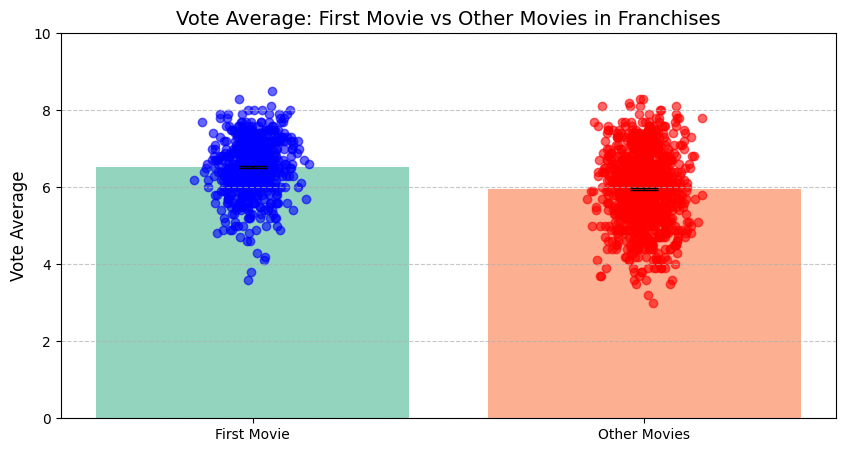


T-test for vote_average of first vs other movies in franchise:
t-statistic: 13.6286992364282
p-value: 8.432273175136465e-40


In [14]:
# πρέπει να ξαναγίνει load γιατί χρειαζόμαστε τη στήλη belongs_to_collection
# την οποία το αρχικό dataframe δεν κρατήσαμε
dataframe8 = pd.read_csv("sample_data/movies_metadata.csv", low_memory=False, on_bad_lines="skip")

# data cleanup (ξανά)
#-------------------------------------------------------------------------------------------------------------------------------------
numeric_columns = ["vote_count", "runtime", "vote_average", "revenue", "budget"]  # πεδία που πρέπει να είναι αριθμοί

for col in numeric_columns:   # για κάθε στήλη numeric
    dataframe8[col] = pd.to_numeric(dataframe8[col], errors="coerce")   # μετέτρεψε σε numeric (αν δεν είναι ήδη)
                                                                      # όπου δεν γίνεται - μετατροπή σε NaN

dataframe8["release_date"] = pd.to_datetime(dataframe8["release_date"], errors="coerce")  # μετατροπή σε data format (αν δεν είναι ήδη)
                                                                                        # όπου δεν γίνεται - μετατροπή σε NaN

# αφαιρεί γραμμές με NaN (not a number) από τις columns που μας ενδιαφέρουν
dataframe8.dropna(subset=["id", "title", "vote_count", "runtime", "vote_average",
    "revenue", "budget", "release_date", "genres"], inplace=True)

# αφαίρεση γραμμών με παράλογες τιμές

# runtime > 0 και < 300
dataframe8 = dataframe8[(dataframe8["runtime"] > 0) & (dataframe8["runtime"] < 300)]

# vote_average μεταξύ 0 και 10
dataframe8 = dataframe8[dataframe8["vote_average"].between(0, 10)]

# budget και revenue μη αρνητικά
dataframe8 = dataframe8[(dataframe8["budget"] >= 0) & (dataframe8["revenue"] >= 0)]
#-------------------------------------------------------------------------------------------------------------------------------------

# κρατάμε μόνο ταινίες με τουλάχιστον 50 votes για να περιορίσουμε ακραίες τιμές
dataframe8 = dataframe8[dataframe8['vote_count'] > 50]

# παίρνουμε το όνομα του franchise
def get_collection_name(x):
    try:
        # μετατροπή string τύπου [{"id":..., "name":...}] list από dictionaries
        d = ast.literal_eval(x)
        # αν είναι dictionary και αν έχει πεδίο name
        if isinstance(d, dict) and 'name' in d:
            return d['name']  # επιστρέφουμε το name του franchise
    except:
        return None   # αν αποτύχει τότε αγνοούμε την ταινία
    return None

# βάζουμε τη στήλη collection με τα ονόματα των franchise
dataframe8['collection'] = dataframe8['belongs_to_collection'].apply(get_collection_name)

# κρατάμε μόνο ταινίες που ανήκουν σε franchise
franchise_movies = dataframe8.dropna(subset=['collection']).copy()

#print(len(franchise_movies))  # αριθμός entries για τις ταινίες που ανήκουν σε franchise

# κρατάμε μόνο franchises με τουλάχιστον 2 ταινίες
# γιατί στη στήλη collection υπάρχουν μερικά franchises με μόνο μια ταινία
valid_collections = franchise_movies['collection'].value_counts()
valid_collections = valid_collections[valid_collections >= 2].index

franchise_movies = franchise_movies[franchise_movies['collection'].isin(valid_collections)]

# μετατροπή release_date σε date format
franchise_movies['release_date'] = pd.to_datetime(franchise_movies['release_date'], errors='coerce')

# sort με βάση το collection και το release_date
franchise_movies = franchise_movies.sort_values(['collection', 'release_date'])

# groupby collection και μετάει τη σειρά εμφάνισης μιας ταινίας στο collection της
franchise_movies['order_in_series'] = franchise_movies.groupby('collection').cumcount() + 1 # +1 γιατί cumcount αρχίζει από 0

# δύο λίστες, μια με τις πρώτες ταινίες, μια με τις υπόλοιπες του franchise (τα vote_average τους)
first_movies = franchise_movies[franchise_movies['order_in_series'] == 1]['vote_average']
non_first_movies = franchise_movies[franchise_movies['order_in_series'] > 1]['vote_average']


groups = ['First Movie', 'Other Movies']
means = [first_movies.mean(), non_first_movies.mean()]
errors = [first_movies.std()/np.sqrt(len(first_movies)), non_first_movies.std()/np.sqrt(len(non_first_movies))]

plt.figure(figsize=(10,5))

# bar plot με μέσο όρο vote_average και error bars (2 μπάρες μια για first και μια για other movies in franchise)
bars = plt.bar(groups, means, yerr=errors, color=['#66c2a5', '#fc8d62'], capsize=10, alpha=0.7)

# κάνουμε scatter τα points πάνω στο bar plot
# χρήση np.random.normal ώστε τα σημεία να μην κάνουν overlap
plt.scatter(np.random.normal(0, 0.05, len(first_movies)), first_movies, color='blue', alpha=0.6)
plt.scatter(np.random.normal(1, 0.05, len(non_first_movies)), non_first_movies, color='red', alpha=0.6)

plt.ylabel("Vote Average", fontsize=12)
plt.title("Vote Average: First Movie vs Other Movies in Franchises", fontsize=14)
plt.ylim(0, 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# t-test
t_stat, p_val = ttest_ind(first_movies, non_first_movies, equal_var=False)

print("")
print("T-test for vote_average of first vs other movies in franchise:")
print("t-statistic:", t_stat)
print("p-value:", p_val)




### Ανάλυση αποτελεσμάτων

Από τη γραφική βλέπουμε ότι οι πρώτες ταινίες των franchise έχουν μέσο όρο γύρω στο 6.5, ενώ οι επόμενες ταινίες είναι εμφανώς πιο χαμηλά, με μέση βαθμολογία περίπου 5.9. Η διαφορά φαίνεται και από το barplot και από τα scatter points βρίσκονται συνολικά ψηλότερα στις πρώτες ταινίες. Το standart error πάνω στα bars δείχνει επίσης ότι τα μέσα είναι διαφορετικά

Όσον αφορά το αποτέλεσμα του t-test, βλέπουμε ότι το p-value είναι πολύ κοντά στο 0 δηλαδή υπάρχει όντως στατιστική σημασία στις διαφορές, άρα η πτώση στη βαθμολογία δεν οφείλεται στην τύχη.